# Import Prerequisites

In [1]:
import numpy as np
import pandas as pd
from glob import glob
from datetime import date, timedelta
import datetime
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from tabulate import tabulate
warnings.filterwarnings("ignore")
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 9

# Dataset Processing

In [3]:
case_time = pd.read_csv('../districts.csv', parse_dates = True)
case_time

,Date,State,District,Confirmed,Recovered,Deceased,Other,Tested
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0,0,2679.0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4,0,NaN
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0,0,NaN
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0,0,NaN
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8,0,NaN
...,...,...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129,0,NaN
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326,0,NaN
258557,2021-06-02,West Bengal,Purulia,18613,17974,107,0,NaN
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111,0,NaN


In [4]:
case_time = case_time[["Date","State","District","Confirmed","Recovered","Deceased"]]
case_time

,Date,State,District,Confirmed,Recovered,Deceased
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8
...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326
258557,2021-06-02,West Bengal,Purulia,18613,17974,107
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111


In [85]:
state = 'Andhra Pradesh'
state_data = case_time[case_time['State'] == state]
state_data

,Date,State,District,Confirmed,Recovered,Deceased
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8
5,2020-04-26,Andhra Pradesh,Krishna,177,29,8
...,...,...,...,...,...,...
257916,2021-06-02,Andhra Pradesh,Srikakulam,109677,101082,581
257917,2021-06-02,Andhra Pradesh,Visakhapatnam,138157,125078,945
257918,2021-06-02,Andhra Pradesh,Vizianagaram,74555,69118,564
257919,2021-06-02,Andhra Pradesh,West Godavari,142088,129719,888


In [86]:
district_list = state_data['District'].unique()

district_data = dict()
district_data_21 = dict()
for districts in district_list:
    district_data.update({districts:0})
for districts in district_list:
    district_data_21.update({districts:0})

In [87]:
#calander like dataframe

sdate = date(2020, 1, 1)
edate = date(2020, 12, 31)

delta = edate - sdate
dates = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates.append(day)

In [88]:
#calander like dataframe

sdate = date(2021, 1, 1)
edate = date(2021, 5, 30)

delta = edate - sdate
dates_21 = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates_21.append(day)

In [89]:
print("Preparing chronological district data for year 2020")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x
    print("=",end="")
            
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data[district] = cal_dat
print(" ||")

Preparing chronological district data for year 2020
|| ================ ||


In [90]:
print("Preparing chronological district data for year 2021")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates_21
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x
    print("=",end="")
            
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data_21[district] = cal_dat
print(" ||")

Preparing chronological district data for year 2021
|| ================ ||


Trend of Active cases in Chittoor for the year 2020


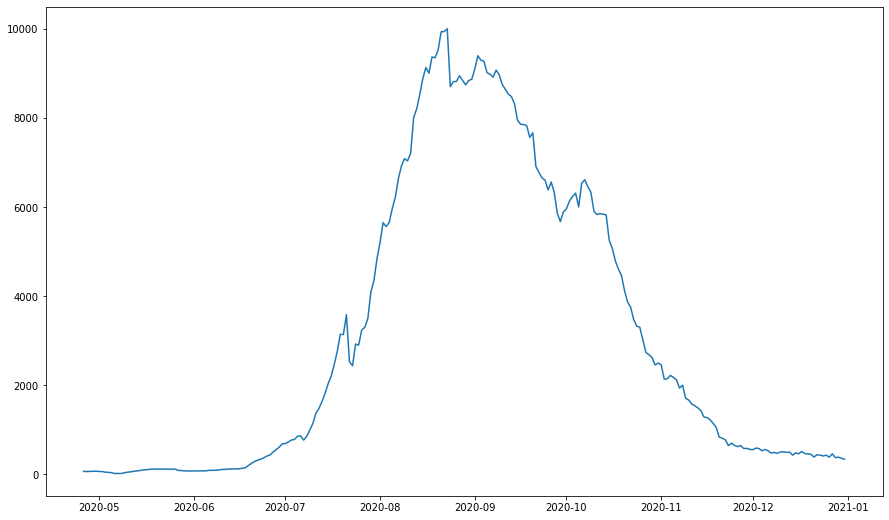

In [91]:
district = 'Chittoor'
pd.set_option('display.max_rows',466)
bang_data = district_data[district][district_data[district]['Active'] != 'DNA']
bang_data = bang_data[["Active"]]
bang_data = bang_data.astype(int)
print("Trend of Active cases in",district,"for the year 2020")
plt.plot(bang_data)

Trend of COVID-19 cases in Chittoor for the year 2021



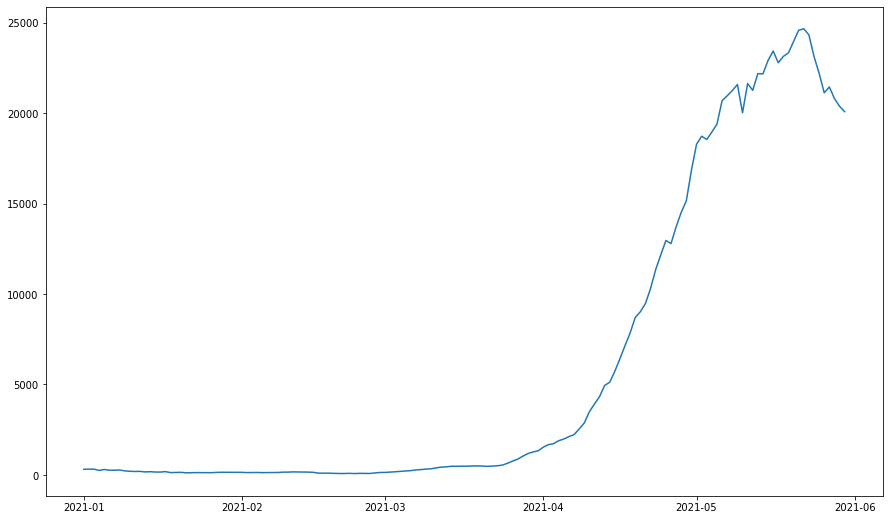

In [92]:
bang_data_21 = district_data_21[district][district_data_21[district]['Active'] != 'DNA']
bang_data_21 = bang_data_21[["Active"]]
bang_data_21 = bang_data_21.astype(int)
print("Trend of COVID-19 cases in",district,"for the year 2021\n")
plt.plot(bang_data_21)

In [93]:
# Divide dataset quarterly

quart_data = bang_data[bang_data.index >= datetime.date(2020, 1, 1)]
quart1_data = bang_data[quart_data.index < datetime.date(2020, 4, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 4, 1)]
quart2_data = bang_data[quart_data.index < datetime.date(2020, 7, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 7, 1)]
quart3_data = quart_data[quart_data.index < datetime.date(2020, 10, 1)]

quart4_data = bang_data[bang_data.index >= datetime.date(2020, 10, 1)]

COVID-19 cases in Chittoor
            Active
Date              
2020-04-26      60
2020-04-27      57
2020-04-28      58
2020-04-29      61
2020-04-30      64
2020-05-01      58
2020-05-02      56
2020-05-03      44
2020-05-04      37
2020-05-05      34
2020-05-06      14
2020-05-07      14
2020-05-08      11
2020-05-09      22
2020-05-10      38
2020-05-11      47
2020-05-12      57
2020-05-13      68
2020-05-14      74
2020-05-15      88
2020-05-16      96
2020-05-17     100
2020-05-18     110
2020-05-19     109
2020-05-20     110
2020-05-21     110
2020-05-22     110
2020-05-23     110
2020-05-24     110
2020-05-25     110
2020-05-26     110
2020-05-27      82
2020-05-28      79
2020-05-29      70
2020-05-30      72
2020-05-31      68
2020-06-01      69
2020-06-02      68
2020-06-03      70
2020-06-04      70
2020-06-05      72
2020-06-06      84
2020-06-07      82
2020-06-08      86
2020-06-09      86
2020-06-10     102
2020-06-11     104
2020-06-12     109
2020-06-13     114
2020

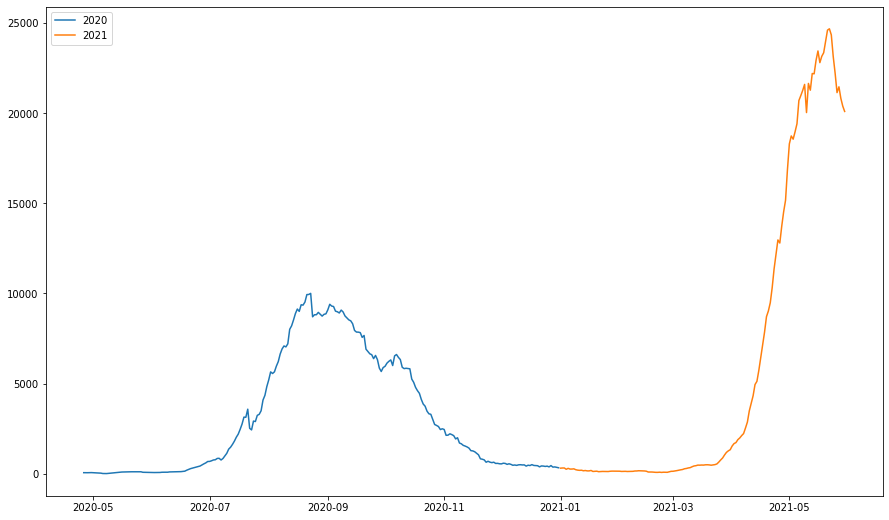

In [94]:
print("COVID-19 cases in",district)
print(bang_data)
print(bang_data_21)
plt.plot(bang_data)
plt.plot(bang_data_21)
plt.legend(['2020','2021'])

# Exponential Smoothing

In [95]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

Forecast of trend of growth of COVID-19 for the 1st test-interval


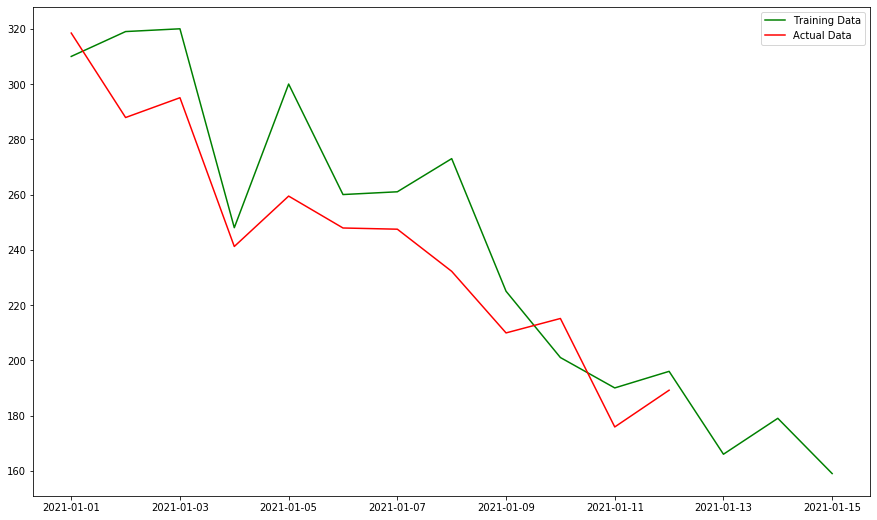

In [96]:
number_of_days = 12
model = ExponentialSmoothing(bang_data,trend='mul',seasonal='mul',seasonal_periods=7).fit()
ress = model.forecast(number_of_days)
print("Forecast of trend of growth of COVID-19 for the 1st test-interval")
plt.plot(bang_data_21[:number_of_days + 3 ],color="green")
plt.plot(ress,color="red")
plt.legend(['Training Data','Actual Data','Forecast'])

In [97]:
lst = bang_data_21.values
sm = 0
l = min(len(bang_data_21),len(ress))
for i in range(l):
    x = (ress[i]-lst[i])**2
    sm = sm + x
rmse = math.sqrt(sm/l)
print('RMSE:',rmse)

RMSE: 22.400513045101782


In [98]:
error_vals =[]

def get_err(ress):
    lst = bang_data_21.values
    sm = 0
    l = min(len(bang_data_21),len(ress))
    for i in range(l):
        x = ((lst[i]-ress[i])/lst[i])**2
        sm = sm + x
    rmse = 100 - (math.sqrt(sm/l))*100
    return rmse

In [99]:
rmse_for_tab = []
model = ExponentialSmoothing(quart4_data,trend='mul',seasonal='mul',seasonal_periods=7).fit()
for i in range(1,15):
    period = int(i)
    ress = model.forecast(period)
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)
error_vals.append(rmse_for_tab)

In [100]:
Q3_4 = pd.concat([quart3_data,quart4_data])

rmse_for_tab = []
model = ExponentialSmoothing(Q3_4,trend='mul',seasonal='mul',seasonal_periods=7).fit()
for i in range(1,15):
    period = int(i)
    ress = model.forecast(period)
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)
error_vals.append(rmse_for_tab)

In [101]:
rmse_for_tab = []
model = ExponentialSmoothing(bang_data,trend='mul',seasonal='mul',seasonal_periods=7).fit()
for i in range(1,15):
    period = int(i)
    ress = model.forecast(period)
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)
error_vals.append(rmse_for_tab)

In [102]:
eval_matrix = pd.DataFrame(columns=['Time frame','Date','Quarter 4 data','Quarter 4 and 3 data','All data'])

In [103]:
tim = []
print("Error comparission for different dataset sizes")
for i in range(len(error_vals[0])):
    tim.append((i+1))
eval_matrix['Time frame'] = tim
eval_matrix['Date'] = bang_data_21.index[:14]
eval_matrix['Quarter 4 data'] = error_vals[0]
eval_matrix['Quarter 4 and 3 data'] = error_vals[1]
eval_matrix['All data'] = error_vals[2]
eval_matrix.set_index('Time frame',inplace=True)
eval_matrix

Error comparission for different dataset sizes


,Date,Quarter 4 data,Quarter 4 and 3 data,All data
Time frame,,,,
1,2021-01-01,95.156793,91.390922,97.272580
2,2021-01-02,92.898779,93.249863,92.837711
3,2021-01-03,93.275801,94.475779,92.619907
4,2021-01-04,93.920259,94.832873,93.463286
5,2021-01-05,91.389616,94.204343,91.589485
6,2021-01-06,91.724393,94.593835,92.090486
7,2021-01-07,92.007447,94.547745,92.419149
8,2021-01-08,90.896069,94.854450,91.157026
9,2021-01-09,91.074187,94.449529,91.368330


Forecast of trend of growth of COVID-19 for the 2nd test interval
Date                   Daily    Cumulative    Confidence Interval    Daily    Cumulative
-------------------  -------  ------------  ---------------------  -------  ------------
2021-05-22 00:00:00      527         24887                97.2726       75         24664
2021-05-23 00:00:00      688         25575                92.8377     -338         24326
2021-05-24 00:00:00     -896         24679                92.6199    -1192         23134
2021-05-25 00:00:00      252         24931                93.4633     -929         22205
2021-05-26 00:00:00      151         25083                91.5895    -1078         21127
2021-05-27 00:00:00      974         26058                92.0905      321         21448
2021-05-28 00:00:00      318         26376                92.4191     -638         20810
2021-05-29 00:00:00      571         26947                91.157      -430         20380


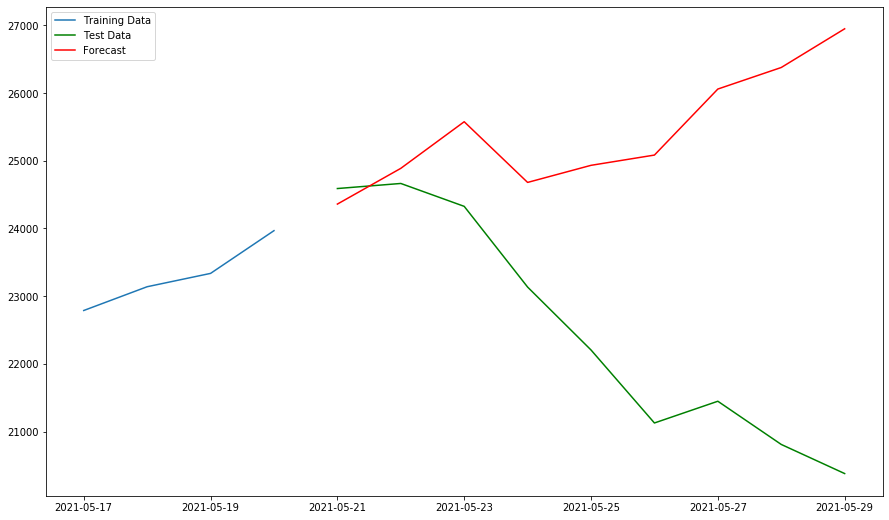

In [104]:
all_data = pd.concat([bang_data,bang_data_21[:-1]])
dayss = 9
trdata = all_data[:-dayss]
tsdata = all_data[-dayss:]
model = ExponentialSmoothing(trdata,trend='mul',seasonal='mul',seasonal_periods=7).fit()
ress = model.forecast(dayss)
print("Forecast of trend of growth of COVID-19 for the 2nd test interval")

        
plt.plot(trdata[-int(dayss/2):])
plt.plot(tsdata,color='green')
plt.plot(ress,color='red')
plt.legend(['Training Data','Test Data','Forecast'])

cum = ress.values
dates = ress.index
daily = []
daily.append(cum[0]-trdata[-1:].values)
data = []
for i in range(1,len(cum)):
    dd = []
    daily.append(cum[i]-cum[i-1])
    dts = tsdata.values[i] - tsdata.values[i-1]
    dd = [dates[i],int(daily[i]),int(cum[i]),eval_matrix['All data'][i],dts,tsdata.values[i]]
    data.append(dd)
print(tabulate(data,headers=['Date','Daily','Cumulative','Confidence Interval','Daily','Cumulative']))

# Future forecast

Future forecast of COVID-19 cases for 8 days
Date                   Daily    Cumulative    Confidence Interval
-------------------  -------  ------------  ---------------------
2021-05-31 00:00:00    -1474         18688                97.2726
2021-06-01 00:00:00     -596         18092                92.8377
2021-06-02 00:00:00     -608         17483                92.6199
2021-06-03 00:00:00       21         17505                93.4633
2021-06-04 00:00:00     -413         17091                91.5895
2021-06-05 00:00:00     -279         16811                92.0905
2021-06-06 00:00:00     -217         16594                92.4191
2021-06-07 00:00:00    -1213         15380                91.157


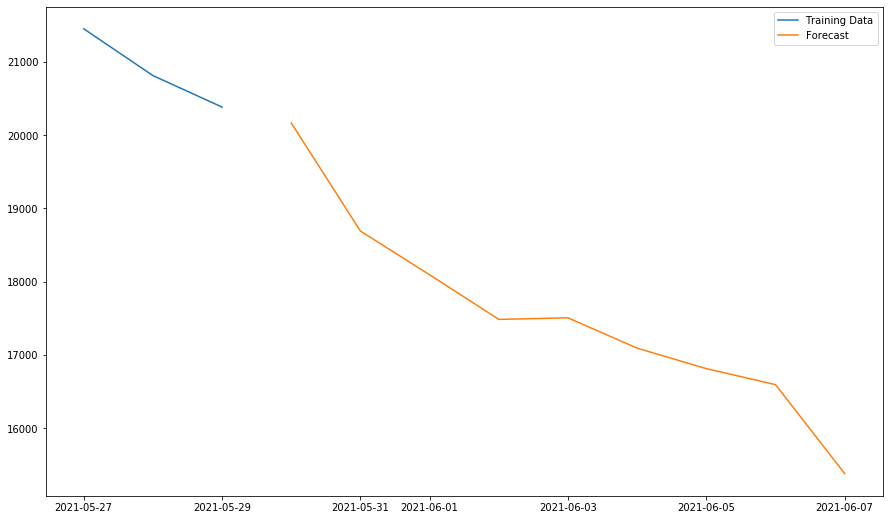

In [105]:
all_data = pd.concat([bang_data,bang_data_21])
model = ExponentialSmoothing(all_data[:-1],trend='mul',seasonal='mul',seasonal_periods=7).fit()
ress = model.forecast(dayss)
plt.plot(all_data[-int(dayss/2):-1])
plt.plot(ress)
plt.legend(['Training Data','Forecast'])
print("Future forecast of COVID-19 cases for",dayss-1,"days")

cum = ress.values
dates = ress.index
daily = []
daily.append(cum[0]-all_data[-1:].values)
data = []
for i in range(1,len(cum)):
    dd = []
    daily.append(cum[i]-cum[i-1])
    dd = [dates[i],int(daily[i]),int(cum[i]),eval_matrix['All data'][i]]
    data.append(dd)
print(tabulate(data,headers=['Date','Daily','Cumulative','Confidence Interval']))